# MLE and Fisher Matrix: Galaxy Clustering

We model the observed galaxy power spectrum

$$P_{\rm gg}(k) = b^2\, P_{\rm m}^{\rm lin}(k;\,\Omega_{\rm m},\,h,\,n_s)$$

where the linear matter power spectrum is computed with CCL. We fit three free parameters
$\boldsymbol{\theta} = (\Omega_{\rm m},\, h,\, b)$ while fixing $n_s$.

The notebook covers:
1. Building a CCL-based linear matter power model.
2. Generating a mock band-power data vector.
3. Maximum-likelihood estimation (MLE) with `scipy.optimize`.
4. Numerical Fisher matrix from the Hessian of $-\ln\mathcal{L}$.
5. A triangle plot with 1D marginals and 2D Fisher ellipses.

### Dependency: CCL

[CCL](https://ccl.readthedocs.io) (Core Cosmology Library) is a C/Python library maintained by the DESC collaboration that provides accurate, validated computations of cosmological quantities — power spectra, distances, growth factors, and more. Here it is used solely to evaluate the linear matter power spectrum $P_{\rm m}^{\rm lin}(k)$ via `ccl.linear_matter_power`.

**Install** (pick one):

```bash
# conda (recommended — links against pre-built C extensions)
conda install -c conda-forge pyccl

# pip
pip install pyccl
```

Requires a C compiler and GSL/FFTW on the system; the `conda-forge` package bundles these automatically.

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize   # Nelder-Mead solver for argmax L(θ), Eq. 4.5
from scipy.stats import chi2          # χ² CDF for p-values (Eq. 4.37) and confidence thresholds (Table 1)
import corner
import shutil
import pyccl as ccl

rng = np.random.default_rng(42)

# Consistent plotting style for all notebook figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'legend.frameon': False,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# Use full LaTeX rendering when available.
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Computer Modern Roman']
else:
    plt.rc('text', usetex=False)

COLORS = {
    'data': '#0A84C1',
    'fid': '#E36A00',
    'mle': '#198754',
    'truth': '#D62728',
    'line1': '#2C7FB8',
    'line2': '#253494',
}


def style_ax(ax):
    ax.minorticks_on()
    ax.grid(False)
    return ax

## 1. Power Spectrum Model

We use the linear matter power spectrum from CCL at $a=1$,

$$P_{\rm m}^{\rm lin}(k) = P_{\rm CCL}(k, a=1;\Omega_{\rm m},h,n_s,\sigma_8),$$

and define the galaxy spectrum as

$$P_{\rm gg}(k) = b^2\,P_{\rm m}^{\rm lin}(k).$$

In the fit below, $h$ and $n_s$ are kept fixed while $(\Omega_{\rm m}, b)$ are inferred.

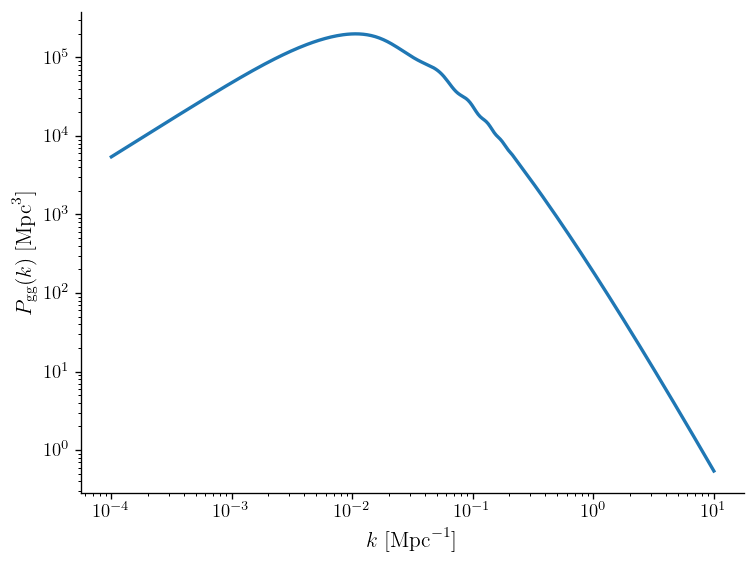

In [138]:
H0_REDUCED = 0.67
OMEGA_B_FIXED = 0.05
SIGMA8_FIXED = 0.81


def galaxy_power_spectrum(k, Omega_m, n_s, b, h=H0_REDUCED):
    """Galaxy power spectrum from CCL linear matter power at a=1.

    This is our model f(x|θ) in the sense of Eq. 4.1: the function that maps
    parameter vector θ = (Ω_m, n_s, b, h) to a predicted data vector.
    The likelihood L(θ) will be built from the residuals between this prediction
    and the observed band powers.
    """
    # CDM density must be positive; clamp to avoid CCL errors at the boundary
    Omega_c = max(Omega_m - OMEGA_B_FIXED, 1e-4)
    cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=OMEGA_B_FIXED,
        h=h,
        n_s=n_s,
        sigma8=SIGMA8_FIXED,
        transfer_function='eisenstein_hu',
        matter_power_spectrum='linear',
    )
    # Linear matter power spectrum at scale factor a=1 (today)
    P_m_lin = ccl.linear_matter_power(cosmo, k, 1.0)
    # Galaxy bias b enters as b², so the galaxy power is b² P_m_lin
    return b**2 * P_m_lin


k_plot = np.logspace(-4, 1, 300)
fig, ax = plt.subplots()
y_plot = galaxy_power_spectrum(k_plot, 0.3, 0.96, 1.5, h=H0_REDUCED)
ax.loglog(k_plot, y_plot, lw=2)
ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{gg}}(k)\;[\mathrm{Mpc}^{3}]$')
style_ax(ax)
plt.tight_layout()
plt.show()

## 2. Mock Data

We observe $N_b$ band powers $\hat{P}_i$ in linearly-spaced $k$-bins of width $\Delta k$.
For a Gaussian random field in survey volume $V_{\rm s}$ the band-power variance is

$$\sigma_i^2 = \frac{2\,P_{\rm gg}^2(k_i)}{N_{\mathrm{modes},i}},
\qquad N_{\mathrm{modes},i} = \frac{4\pi k_i^2\,\Delta k}{(2\pi)^3/V_{\rm s}}.$$

The mock data are a single Gaussian realisation around the fiducial model.

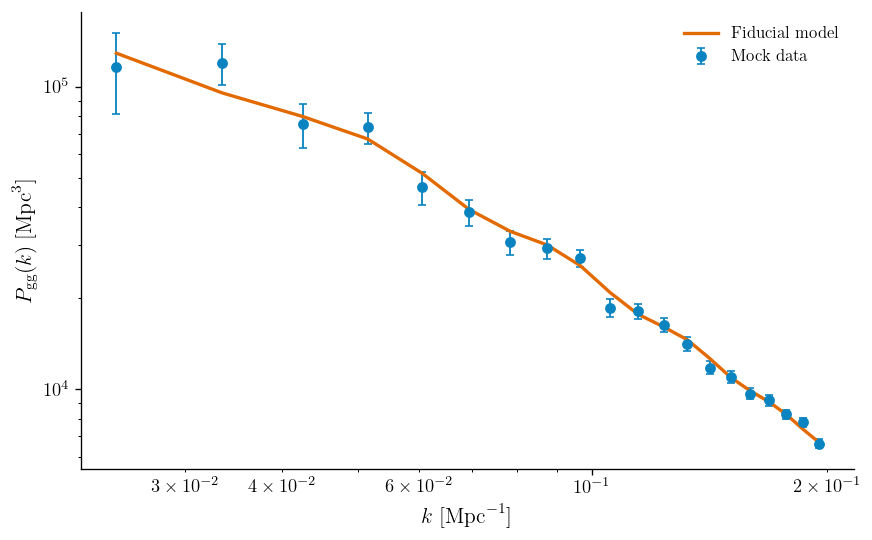

In [140]:
# ── Survey and binning geometry (you can ignore this) ────────────────────────
V_s    = 1.0e8         # Survey volume Mpc^3
N_bins = 20             # Number of k-bins → n=20 iid observations (Eq. 4.1)
k_edges = np.linspace(0.02, 0.20, N_bins + 1)
k_cents = 0.5 * (k_edges[:-1] + k_edges[1:])
dk      = k_edges[1] - k_edges[0]

# ── True (fiducial) parameter vector θ₀ ──────────────────────────────────────
# θ₀ is the fixed, unknown truth that the MLE will try to recover (Fig. 11)
theta_true = np.array([0.30, 0.67, 0.96, 1.50])
Om_t, h_t, ns_t, b_t = theta_true

# ── Fiducial model prediction ─────────────────────────────────────────────────
P_fid   = galaxy_power_spectrum(k_cents, Om_t, ns_t, b_t, h=h_t)

# ── Band-power noise variance ──────────────────────────────────────────────────
# For a Gaussian random field, the variance of a band-power estimate is
#   σ_i² = 2 P²(k_i) / N_modes,i   with   N_modes,i = 4π k_i² Δk V_s / (2π)³
# This is the diagonal covariance C = diag(σ_i²) that appears in Eq. 4.35.
N_modes = 4.0 * np.pi * k_cents**2 * dk * V_s / (2.0 * np.pi)**3
sigma_P = np.sqrt(2.0 / N_modes) * P_fid

# ── Single Gaussian realisation of the data ───────────────────────────────────
# Each P̂_i ~ N(P_fid(k_i), σ_i²) independently: this is one draw of the
# n iid random variables X_1,...,X_n whose joint PDF factorises as Eq. 4.1.
# Once observed, these values are fixed; L(θ) then becomes a deterministic
# function of θ (not of the data), as emphasised in Sec. 4.1.
P_obs = P_fid + rng.normal(0.0, sigma_P)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.errorbar(
    k_cents, P_obs, yerr=sigma_P, fmt='o', ms=5.5, lw=1,
    color=COLORS['data'], ecolor=COLORS['data'], elinewidth=1.1, capsize=2.5,
    label='Mock data'
)
ax.plot(k_cents, P_fid, lw=2, color=COLORS['fid'], label='Fiducial model')
ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{gg}}(k)\;[\mathrm{Mpc}^{3}]$')
ax.legend(loc='upper right')
plt.loglog()
style_ax(ax)
plt.tight_layout()
plt.show()

## 3. Likelihood and MLE

Assuming independent Gaussian band powers with noise $\sigma_i$ fixed at the fiducial,
the log-likelihood is

$$\ln\mathcal{L}(\boldsymbol{\theta}) =
-\frac{1}{2}\sum_i\frac{\bigl(\hat{P}_i - P_{\mathrm{gg}}(k_i;\boldsymbol{\theta})\bigr)^2}{\sigma_i^2}.$$

We minimise $-\ln\mathcal{L}$ with the Nelder-Mead simplex method for
$\boldsymbol{\theta}=(\Omega_{\rm m}, h, b)$ while keeping $n_s$ fixed.

Converged: True
  Fixed: n_s=0.9600
  True:  Omega_m=0.3000  h=0.6700  b=1.5000
  MLE :  Omega_m=0.3234  h=0.6476  b=1.4584
  chi2        = 13.42
  dof         = 17
  chi2_red    = 0.789  (expect ~1 for a good fit)
  p-value     = 0.708


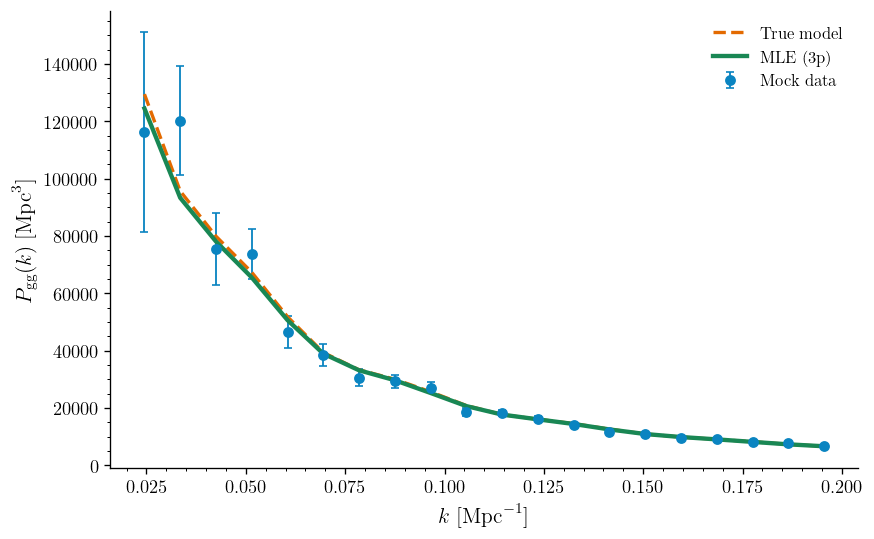

In [ ]:
# n_s is held fixed; we fit d=3 free parameters: θ = (Ω_m, h, b)
ns_fixed = ns_t


def neg_log_like(theta):
    """Negative log-likelihood −L(θ) for the Gaussian band-power model.

    The log-likelihood is (Eq. 4.4):
        L(θ) = Σ_i ln f(P̂_i | θ) = −½ Σ_i (P̂_i − P_gg(k_i;θ))² / σ_i²
                                      + const.
    which is exactly −½ χ²(θ) (Eq. 4.35) for diagonal covariance C = diag(σ_i²).
    Minimising −L(θ) is equivalent to maximising L(θ), i.e. finding the MLE
    θ̂_MLE = argmax L(θ) (Eq. 4.5).

    Hard boundaries (Om,h,b > 0) return a large penalty instead of letting CCL
    crash;
    """
    Om, h, b = theta
    if Om <= 0 or h <= 0 or b <= 0:
        return 1e30
    P_mod = galaxy_power_spectrum(k_cents, Om, ns_fixed, b, h=h)
    # Each term is one contribution L_i(θ) to the sum in Eq. 4.4
    return 0.5 * np.sum(((P_obs - P_mod) / sigma_P)**2)


# ── Solve ∇_θ L = 0 numerically (score equation, Eq. 4.6) ────────────────────
# Nelder-Mead does not require gradients, which is convenient here because CCL
# evaluations are expensive and no analytic score function is available.
result = minimize(
    neg_log_like,
    x0=[0.28, 0.65, 1.4],       # Starting point near the truth
    method='Nelder-Mead',
    options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 30000},
)

theta_mle = result.x            # θ̂_MLE: the value maximising L(θ)
theta_true_fit = np.array([Om_t, h_t, b_t])
print('Converged:', result.success)
print(f'  Fixed: n_s={ns_fixed:.4f}')
print(f'  True:  Omega_m={Om_t:.4f}  h={h_t:.4f}  b={b_t:.4f}')
print(f'  MLE :  Omega_m={theta_mle[0]:.4f}  h={theta_mle[1]:.4f}  b={theta_mle[2]:.4f}')

# ── Goodness-of-fit statistics (Sec. 4.9) ─────────────────────────────────────
# At the MLE, χ²_min = −2 L(θ̂_MLE) ~ χ²_ν with ν = n − d degrees of freedom
# (Eq. 4.36): n=20 data points minus d=3 fitted parameters.
chi2_mle = 2.0 * neg_log_like(theta_mle)   # χ²_min
ndof = len(k_cents) - len(theta_mle)        # ν = n − d = 17
chi2_red = chi2_mle / ndof                  # χ²_red = χ²_min / ν

# p-value: probability of obtaining χ² ≥ χ²_obs under the true model (Eq. 4.37)
# Small p → poor fit (model incompatible with data); p is NOT P(model is correct)
p_value = chi2.sf(chi2_mle, ndof)          # chi2.sf = 1 − F_{χ²_ν}(χ²_min)

print(f'  chi2        = {chi2_mle:.2f}')
print(f'  dof         = {ndof:d}')
print(f'  chi2_red    = {chi2_red:.3f}  (expect ~1 for a good fit)')
print(f'  p-value     = {p_value:.3f}')

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.errorbar(
    k_cents, P_obs, yerr=sigma_P, fmt='o', ms=5.5, lw=1,
    color=COLORS['data'], ecolor=COLORS['data'], elinewidth=1.1, capsize=2.5,
    label='Mock data'
)
ax.plot(k_cents, P_fid, lw=2, ls='--', color=COLORS['fid'], label='True model')
ax.plot(
    k_cents,
    galaxy_power_spectrum(k_cents, theta_mle[0], ns_fixed, theta_mle[2], h=theta_mle[1]),
    lw=2.6, color=COLORS['mle'], label='MLE (3p)'
)
ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{gg}}(k)\;[\mathrm{Mpc}^{3}]$')
ax.legend(loc='upper right')
style_ax(ax)
plt.tight_layout()
plt.show()

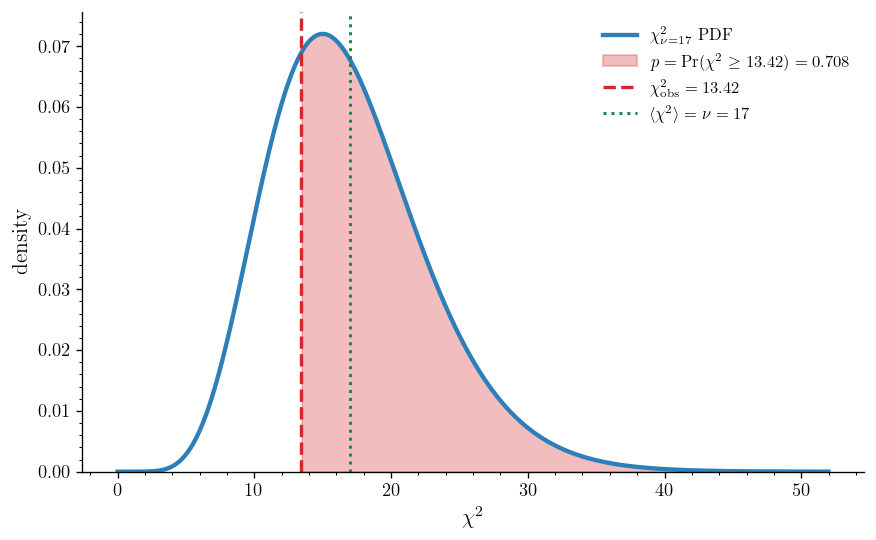

In [149]:
# ── Visualise the p-value as the right tail of the χ²_ν distribution ──────────
# The p-value is a frequentist concept (Sec. 4.9): it is the probability of
# obtaining χ² ≥ χ²_obs if the experiment were repeated many times under the
# true model.  It does NOT measure whether the model is correct — that is a
# Bayesian question (Sec. 5).
# χ²_red ≈ 1 → the fit is consistent with the data scatter; χ²_red >> 1 would
# indicate underfitting or underestimated uncertainties.
x_chi = np.linspace(0.0, max(chi2_mle * 1.6, ndof + 6.0 * np.sqrt(2.0 * ndof)), 800)
pdf_chi = chi2.pdf(x_chi, ndof)   # χ²_ν PDF; expectation E[Q] = ν (Sec. 4.8)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(x_chi, pdf_chi, lw=2.6, color=COLORS['line1'], label=rf'$\chi^2_{{\nu={ndof}}}$ PDF')

# Shaded right tail: area = p = P(χ² ≥ χ²_obs) — Eq. 4.37
mask = x_chi >= chi2_mle
ax.fill_between(x_chi[mask], pdf_chi[mask], color=COLORS['truth'], alpha=0.30,
                label=rf'$p=\mathrm{{Pr}}(\chi^2\geq {chi2_mle:.2f})={p_value:.3f}$')

ax.axvline(chi2_mle, color=COLORS['truth'], lw=2.0, ls='--',
           label=rf'$\chi^2_\mathrm{{obs}}={chi2_mle:.2f}$')

# The expectation E[χ²] = ν marks the "ideal" location of a perfect fit
ax.axvline(ndof, color=COLORS['mle'], lw=1.8, ls=':',
           label=rf'$\langle\chi^2\rangle=\nu={ndof}$')

ax.set_xlabel(r'$\chi^2$', fontsize=13)
ax.set_ylabel('density', fontsize=13)
ax.set_ylim(0.0, ax.get_ylim()[1] * 1.)
ax.legend(loc='upper right')
style_ax(ax)
plt.tight_layout()
plt.show()

## 4. Fisher Matrix

The Fisher information matrix is the Hessian of $-\ln\mathcal{L}$ at the MLE:

$$F_{ij} = \left.\frac{\partial^2(-\ln\mathcal{L})}{\partial\theta_i\,\partial\theta_j}\right|_{\hat{\boldsymbol{\theta}}}$$

computed with a central finite-difference scheme for
$\boldsymbol{\theta}=(\Omega_{\rm m}, h, b)$.
The Cramér-Rao bound gives
$\mathrm{Cov}(\hat{\boldsymbol{\theta}}) \geq F^{-1}$, with equality for the MLE of an
exponential-family likelihood.

Fisher matrix F:
[[  7468.06  -5312.22   7449.05]
 [ -5312.22  17113.92 -13499.04]
 [  7449.05 -13499.04  12571.03]]

Covariance C = F^{-1}:
[[ 0.003365 -0.003452 -0.005701]
 [-0.003452  0.003924  0.00626 ]
 [-0.005701  0.00626   0.01018 ]]

  Omega_m     MLE = 0.3234  +/-  0.05800
  h           MLE = 0.6476  +/-  0.06264
  b           MLE = 1.4584  +/-  0.10089


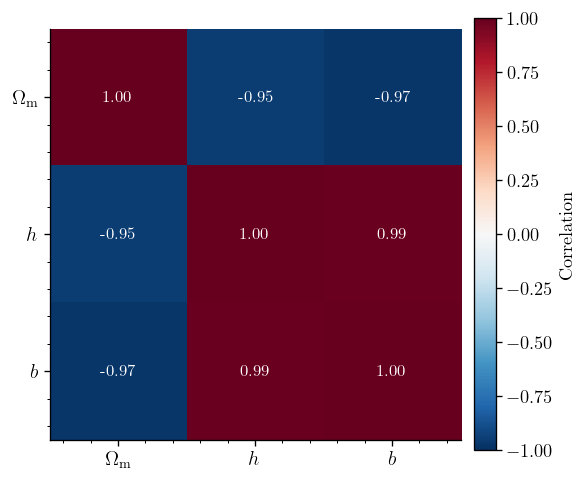

In [150]:
def numerical_hessian(f, x, eps_frac=1e-4):
    """Central finite-difference Hessian of scalar f at point x.

    At the MLE the Hessian of −L equals the Fisher information matrix (Eq. 4.19):
        F_αβ(θ) = −⟨∂_α ∂_β L(θ)⟩  =  ⟨∂_α L · ∂_β L⟩
    Both forms are equivalent under the regularity conditions of Sec. 4.2.
    Numerically we evaluate −∂_α ∂_β L at θ̂_MLE (not at θ₀, which is unknown)
    as justified by the asymptotic result Eq. 4.27.
    """
    n   = len(x)
    eps = np.abs(x) * eps_frac + 1e-6   # Per-parameter step size
    H   = np.zeros((n, n))
    f0  = f(x)
    for i in range(n):
        ei = np.zeros(n); ei[i] = eps[i]
        # Diagonal: second derivative via second-order central difference
        H[i, i] = (f(x + ei) - 2.0*f0 + f(x - ei)) / eps[i]**2
        for j in range(i + 1, n):
            ej = np.zeros(n); ej[j] = eps[j]
            # Off-diagonal: mixed partial via four-point stencil
            H[i,j] = (f(x+ei+ej) - f(x+ei-ej) - f(x-ei+ej) + f(x-ei-ej)) / (4*eps[i]*eps[j])
            H[j,i] = H[i,j]   # F is symmetric by construction
    return H


# ── Fisher matrix F = Hess(−L) at θ̂_MLE ─────────────────────────────────────
# For n iid data points F^(n) = n F (Eq. 4.20): independent information is additive.
# The curvature of L at the MLE measures how sharply the data constrain θ (Fig. 12):
# a steep (large F) log-likelihood → tight constraints; a flat one → loose constraints.
Fisher = numerical_hessian(neg_log_like, theta_mle)

# ── Cramér–Rao bound (Eq. 4.26): Cov(θ̂) ≥ F⁻¹/n ─────────────────────────────
# The MLE saturates this bound asymptotically (asymptotic efficiency, Sec. 4.4),
# so C = F⁻¹ is the (approximate) covariance matrix of θ̂_MLE (Eq. 4.27).
C_mle  = np.linalg.inv(Fisher)

# Marginal 1σ uncertainties: σ_α = sqrt((F⁻¹)_αα) — Eq. 4.49 (with z_{α/2}=1)
# Note: this is the α-th diagonal of F⁻¹, NOT 1/F_αα; they differ when
# parameters are correlated (Eq. 4.50).
sigmas = np.sqrt(np.diag(C_mle))

print('Fisher matrix F:')
print(np.array2string(Fisher, precision=2, suppress_small=True))
print()
print('Covariance C = F^{-1}:')
print(np.array2string(C_mle, precision=6, suppress_small=True))
print()
for name, val, sig in zip(['Omega_m', 'h', 'b'], theta_mle, sigmas):
    print(f'  {name:10s}  MLE = {val:.4f}  +/-  {sig:.5f}')

# ── Correlation matrix ─────────────────────────────────────────────────────────
# Off-diagonal entries ρ_αβ ≠ 0 mean the ellipses are tilted (Fig. 18 left).
# Marginalising over nuisance parameters always broadens uncertainties (Eq. 4.50).
corr = C_mle / np.outer(np.diag(C_mle)**0.5, np.diag(C_mle)**0.5)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
cb = plt.colorbar(im, ax=ax, fraction=0.05, pad=0.03)
cb.set_label('Correlation', fontsize=11)
tlabels = [r'$\Omega_{\mathrm{m}}$', r'$h$', r'$b$']
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(tlabels, fontsize=12)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(tlabels, fontsize=12)
for i in range(3):
    for j in range(3):
        txt_col = 'white' if abs(corr[i, j]) > 0.55 else 'black'
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=10, color=txt_col)
style_ax(ax)
plt.tight_layout()
plt.show()

## 5. Fisher Triangle Plot

Under the Laplace (Gaussian) approximation around the MLE,

$$p(\boldsymbol{\theta}\mid\mathrm{data}) \approx \mathcal{N}(\hat{\boldsymbol{\theta}},\, C), \qquad C = F^{-1}.$$

The triangle plot shows:
1. 1D Gaussian marginals on the diagonal.
2. 2D marginalised Fisher ellipses for each parameter pair in the lower triangle.

For each parameter pair, 68% and 95% regions correspond to
$\Delta\chi^2=2.30$ and $5.99$.

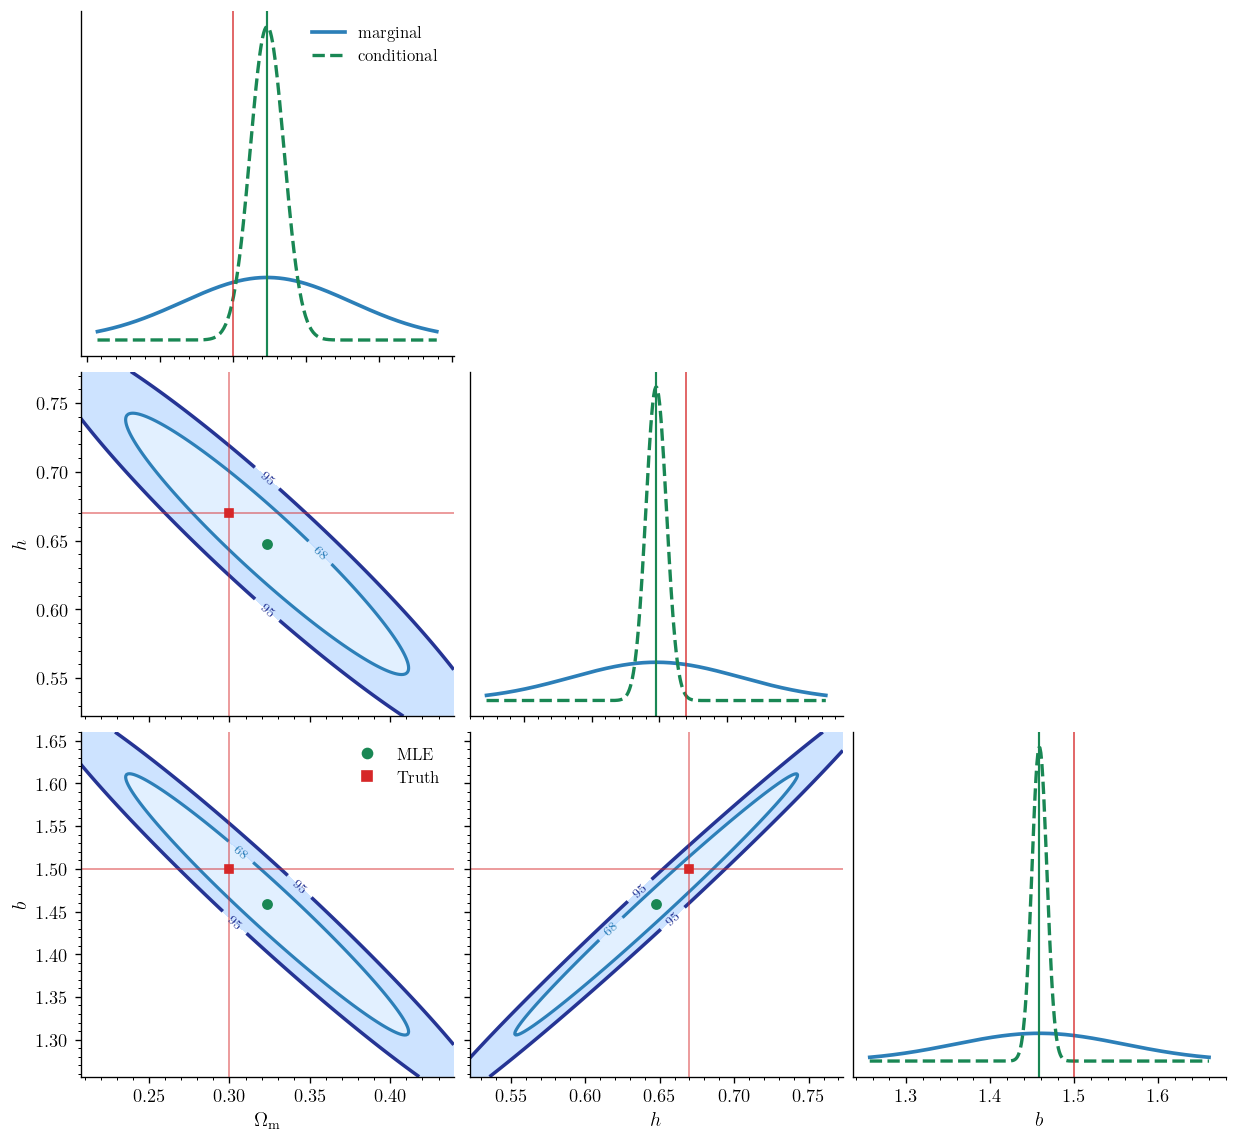

In [152]:
# ── Triangle plot: 1D marginals + 2D pairwise Fisher ellipses ─────────────────
# Under the Gaussian approximation (Eq. 4.27), the full joint posterior is
#   θ̂_MLE ~ N(θ̂_MLE, C),  C = F⁻¹
# and every marginal is also Gaussian (Eq. 4.48).
#
# The 2D confidence ellipses in the off-diagonal panels are drawn at χ²_{d=2}
# thresholds from Table 1:
#   68% coverage: Δχ² = 2.30   (L drops by ½ × 2.30 = 1.15 from maximum)
#   95% coverage: Δχ² = 5.99   (L drops by ½ × 5.99 = 3.00 from maximum)
# These are JOINT thresholds for d=2 parameters, larger than the naive 1σ/2σ
# of a single parameter (Δχ² = 1/4) — see Fig. 17 and the discussion in Sec. 4.10.
labels = [r'$\Omega_{\mathrm{m}}$', r'$h$', r'$b$']
mu = theta_mle
C = C_mle
truth = theta_true_fit
npar = 3
F_full = np.linalg.inv(C)

# χ²_{d=2} quantiles for 68% and 95% (Table 1, d=2 column)
levels = [2.30, 5.99]


def gauss_1d(z, mu0, sig0):
    return np.exp(-0.5 * ((z - mu0) / sig0) ** 2) / (np.sqrt(2.0 * np.pi) * sig0)

nsigma = 2
fig, axes = plt.subplots(npar, npar, figsize=(10.2, 9.4), constrained_layout=True)

for i in range(npar):
    for j in range(npar):
        ax = axes[i, j]

        if i < j:
            ax.axis('off')
            continue

        if i == j:
            # ── Diagonal: 1D marginal and conditional distributions ─────────
            # Marginal σ_α = sqrt((F⁻¹)_αα) integrates out all other parameters
            # and is wider than the conditional σ_α = 1/sqrt(F_αα), which fixes
            # all other parameters at their MLE values (Eq. 4.49 vs Sec. 4.11).
            sig_marg = np.sqrt(C[i, i])         # Marginal 1σ (Eq. 4.49)
            sig_cond = 1.0 / np.sqrt(F_full[i, i])  # Conditional 1σ (narrowest)
            x = np.linspace(mu[i] - nsigma * sig_marg, mu[i] + nsigma * sig_marg, 350)
            pdf_marg = gauss_1d(x, mu[i], sig_marg)
            pdf_cond = gauss_1d(x, mu[i], sig_cond)

            if i == 0:
                ax.plot(x, pdf_marg, color=COLORS['line1'], lw=2.2, label='marginal')
                ax.plot(x, pdf_cond, color=COLORS['mle'], lw=2.0, ls='--', label='conditional')
                ax.legend(loc='upper right', fontsize=10)
            else:
                ax.plot(x, pdf_marg, color=COLORS['line1'], lw=2.2)
                ax.plot(x, pdf_cond, color=COLORS['mle'], lw=2.0, ls='--')

            ax.axvline(mu[i], color=COLORS['mle'], lw=1.3)
            ax.axvline(truth[i], color=COLORS['truth'], lw=1.1, alpha=0.75)
            ax.set_yticks([])
            if i == npar - 1:
                ax.set_xlabel(labels[i], fontsize=12)
            else:
                ax.tick_params(labelbottom=False)
            style_ax(ax)
            continue

        # ── Lower triangle: pairwise marginalised 2D Fisher ellipses ─────────
        # For each 2-parameter sub-space, marginalise over the third by projecting
        # onto the 2×2 sub-matrix of C (the marginal of a multivariate Gaussian
        # is Gaussian, Eq. 4.48).  The ellipse boundary satisfies Δχ² ≤ threshold
        # (Eq. 4.44), which is a quadratic form in (θ − θ̂_MLE) (Eq. 4.38).
        sub_idx = [j, i]
        mu2 = mu[sub_idx]
        C2 = C[np.ix_(sub_idx, sub_idx)]   # 2×2 marginal covariance
        F2 = np.linalg.inv(C2)             # 2×2 marginal precision
        sig2 = np.sqrt(np.diag(C2))

        x = np.linspace(mu2[0] - nsigma * sig2[0], mu2[0] + nsigma * sig2[0], 260)
        y = np.linspace(mu2[1] - nsigma * sig2[1], mu2[1] + nsigma * sig2[1], 260)
        X, Y = np.meshgrid(x, y)
        DX = X - mu2[0]
        DY = Y - mu2[1]
        # Δχ² = (θ−θ̂)ᵀ F₂ (θ−θ̂): the quadratic form in Eq. 4.38 for d=2
        Delta = F2[0, 0] * DX**2 + 2.0 * F2[0, 1] * DX * DY + F2[1, 1] * DY**2

        ax.contourf(
            X, Y, Delta,
            levels=[0, levels[0], levels[1]],
            colors=['#d7ebff', '#b8d8ff', '#eef5ff'],
            alpha=0.70,
        )
        cs = ax.contour(
            X, Y, Delta,
            levels=levels,
            colors=[COLORS['line1'], COLORS['line2']],
            linewidths=[1.9, 2.1],
        )
        ax.clabel(cs, inline=True, fmt={2.30: '68%', 5.99: '95%'}, fontsize=8)

        ax.plot(mu2[0], mu2[1], marker='o', ms=5.5, color=COLORS['mle'])
        ax.plot(truth[sub_idx[0]], truth[sub_idx[1]], marker='s', ms=5.0, color=COLORS['truth'])
        ax.axvline(truth[sub_idx[0]], color=COLORS['truth'], lw=0.9, alpha=0.6)
        ax.axhline(truth[sub_idx[1]], color=COLORS['truth'], lw=0.9, alpha=0.6)

        if i == npar - 1:
            ax.set_xlabel(labels[j], fontsize=12)
        else:
            ax.tick_params(labelbottom=False)

        if j == 0:
            ax.set_ylabel(labels[i], fontsize=12)
        else:
            ax.tick_params(labelleft=False)

        style_ax(ax)

# Legend in lower-left panel
axes[2, 0].plot([], [], marker='o', color=COLORS['mle'], linestyle='None', label='MLE')
axes[2, 0].plot([], [], marker='s', color=COLORS['truth'], linestyle='None', label='Truth')
axes[2, 0].legend(loc='upper right', fontsize=10)

plt.show()